In [110]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score
import time
import shap
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
class OutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds = {}
        self.upper_bounds = {}

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        for col in X_df.columns:
            Q1 = X_df[col].quantile(0.25)
            Q3 = X_df[col].quantile(0.75)
            IQR = Q3 - Q1
            self.lower_bounds[col] = Q1 - self.factor * IQR
            self.upper_bounds[col] = Q3 + self.factor * IQR
        return self

    def transform(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        for col in X_df.columns:
            # Capping (Winsorization)
            X_df[col] = np.where(X_df[col] < self.lower_bounds[col], self.lower_bounds[col], X_df[col])
            X_df[col] = np.where(X_df[col] > self.upper_bounds[col], self.upper_bounds[col], X_df[col])
        return X_df.values

In [112]:
df = pd.read_csv('./dataset/UCI/cleveland.csv')

In [113]:
df.duplicated().sum()

np.int64(0)

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 33.3+ KB


In [115]:
df['target'].value_counts()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [116]:
df['target'] = np.where(df['target'] == 0, 0, 1)

In [117]:
df = df.replace("?", pd.NA)

df = df.apply(pd.to_numeric, errors='coerce')

In [118]:
X = df.drop('target', axis=1)
y = df['target']

X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

list_col_full = [
    'age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal'
]

num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_features = ['slope', 'ca','sex', 'fbs', 'exang','cp', 'restecg', 'thal']

In [119]:
Y_train.value_counts()

target
0    131
1    111
Name: count, dtype: int64

In [120]:
X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,48,1,4,124,274,0,2,166,0,0.5,2,0.0,7.0
208,55,1,2,130,262,0,0,155,0,0.0,1,0.0,3.0
167,54,0,2,132,288,1,2,159,1,0.0,1,1.0,3.0
105,54,1,2,108,309,0,0,156,0,0.0,1,0.0,7.0
297,57,0,4,140,241,0,0,123,1,0.2,2,0.0,7.0


PREPROCESSING DATA KNN-SVM-LR

In [121]:
num_pipeline_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("outlier", OutlierHandler()),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_scaled = ColumnTransformer([
    ("num", num_pipeline_scaled, num_features),
    ("cat", cat_pipeline, cat_features)
])

num_pipeline_LR = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("outlier", OutlierHandler()),
    ("scaler", StandardScaler())
])

cat_pipeline_LR = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop='first',handle_unknown="ignore"))
])

preprocess_LR = ColumnTransformer([
    ("num", num_pipeline_LR, num_features),
    ("cat", cat_pipeline_LR, cat_features)
])

Decision Tree, Random Forest, Bagging

In [122]:
num_pipeline_no_scale = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess_tree = ColumnTransformer([
    ("num", num_pipeline_no_scale, num_features),
    ("cat", cat_pipeline, cat_features)
])

XGBoost, AdaBoost

In [123]:
preprocess_boost = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), num_features),
    
    ("cat", cat_pipeline, cat_features)
])

In [124]:
CatBoostClassifier(cat_features=cat_features)

CatBoostClassifier(cat_features=['slope', 'ca', 'sex', 'fbs', 'exang', 'cp', 'restecg', 'thal'])

In [125]:
pipe_knn = Pipeline([
    ("preprocess", preprocess_LR),
    ("model", KNeighborsClassifier())
])

pipe_lr = Pipeline([
    ("preprocess", preprocess_scaled),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_svm = Pipeline([
    ("preprocess", preprocess_scaled),
    ("model", SVC(probability=True))
])

pipe_dt = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", DecisionTreeClassifier())
])

pipe_rf = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", RandomForestClassifier())
])

pipe_bagging = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100
    ))
])

pipe_xgb = Pipeline([
    ("preprocess", preprocess_boost),
    ("model", XGBClassifier(eval_metric='logloss'))
])

pipe_ada = Pipeline([
    ("preprocess", preprocess_boost),
    ("model", AdaBoostClassifier())
])

pipe_cat = Pipeline([
    ("preprocess", preprocess_boost),
    ("model", CatBoostClassifier(verbose=0))
])

In [126]:
pipelines = {
    "KNN": pipe_knn,
    "LR": pipe_lr,
    "SVM": pipe_svm,
    "DT": pipe_dt,
    "RF": pipe_rf,
    "Bagging": pipe_bagging,
    "XGB": pipe_xgb,
    "Ada": pipe_ada,
    "CatBoost": pipe_cat
}

In [127]:
param_knn = {
    "model__n_neighbors": [3,5,7,9,11],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

param_lr = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

param_svm = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["rbf", "linear"],
    "model__gamma": ["scale", "auto"]
}

param_dt = {
    "model__max_depth": [3,5,10,20,None],
    "model__min_samples_split": [2,5,10],
    "model__min_samples_leaf": [1,2,4],
    "model__criterion": ["gini", "entropy"]
}

param_rf = {
    "model__n_estimators": [100,200,300],
    "model__max_depth": [None,5,10,20],
    "model__min_samples_split": [2,5],
    "model__min_samples_leaf": [1,2],
    "model__max_features": ["sqrt", "log2"]
}

param_bagging = {
    "model__n_estimators": [50,100,200],
    "model__max_samples": [0.5, 0.7, 1.0],
    "model__max_features": [0.5, 0.7, 1.0]
}

param_xgb = {
    "model__n_estimators": [100,200,300],
    "model__max_depth": [3,5,7],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

param_ada = {
    "model__n_estimators": [50,100,200],
    "model__learning_rate": [0.01, 0.1, 1]
}

param_cat = {
    "model__iterations": [100,200,300],
    "model__depth": [4,6,8],
    "model__learning_rate": [0.01, 0.1],
    "model__l2_leaf_reg": [1,3,5]
}

In [128]:
param_grids = {
    "KNN": param_knn,
    "LR": param_lr,
    "SVM": param_svm,
    "DT": param_dt,
    "RF": param_rf,
    "Bagging": param_bagging,
    "XGB": param_xgb,
    "Ada": param_ada,
    "CatBoost": param_cat
}

ĐÁNH GIÁ BASELINE

In [129]:
# baseline_results = []
# for name, pipe in pipelines.items():
#     # Cross-validation score với default params
#     cv_scores = cross_val_score(pipe, X_train, Y_train, cv=5, scoring='roc_auc')
#     baseline_results.append({
#         "Model": name,
#         "CV AUC Mean": cv_scores.mean(),
#         "CV AUC Std": cv_scores.std()
#     })

# baseline_df = pd.DataFrame(baseline_results).sort_values("CV AUC Mean", ascending=False)
# print(baseline_df.to_string(index=False))

In [130]:

best_models = {}
evaluation_results = []
logistic_regression_models = {}  # Lưu riêng hệ số của LR

for name, pipe in pipelines.items():
    print(f"[{name}] Đang huấn luyện với GridSearchCV...")
    if name == 'SVM' or name == 'Bagging' or name == 'CatBoost':
        continue
    
    # 1. Huấn luyện GridSearchCV
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        return_train_score=True,
        verbose=1
    )
    
    start_time = time.time()
    grid.fit(X_train, Y_train)
    end_time = time.time()
    training_time = end_time - start_time
    
    best_models[name] = grid.best_estimator_
    
    # LƯU HỆ SỐ CHO LOGISTIC REGRESSION
    if name == 'LR':
        # Lấy tên features
        preprocessor = grid.best_estimator_.named_steps["preprocess"]
        
        # Lấy tên numerical features
        num_features_names = num_features
        
        # Lấy tên categorical features sau OneHotEncoder
        cat_encoder = preprocessor.named_transformers_["cat"].named_steps["encoder"]
        cat_features_names = cat_encoder.get_feature_names_out(cat_features).tolist()
        
        # Gộp tất cả features
        all_features = num_features_names + cat_features_names
        
        # Lấy model LR và hệ số
        lr_model = grid.best_estimator_.named_steps["model"]
        coefficients = lr_model.coef_[0]
        
        # Lưu vào dictionary
        logistic_regression_models[name] = {
            "features": all_features,
            "coefficients": coefficients,
            "best_params": grid.best_params_,
            "auc": roc_auc_score(Y_test, grid.best_estimator_.predict_proba(X_test)[:, 1])
        }
    
    # 2. Dự đoán xác suất cho nhãn Positive (1)
    y_probs = grid.best_estimator_.predict_proba(X_test)[:, 1]
    
    # 3. Tính toán ROC AUC và tìm ngưỡng cắt (Threshold) tối ưu
    auc = roc_auc_score(Y_test, y_probs)
    fpr, tpr, thresholds = roc_curve(Y_test, y_probs)
    
    # Sử dụng Youden's J statistic
    J = tpr - fpr
    optimal_idx = np.argmax(J)
    optimal_threshold = thresholds[optimal_idx]
    
    # 4. Dự đoán dựa trên ngưỡng vừa tìm được
    y_pred = (y_probs >= optimal_threshold).astype(int)
    
    # 5. Đánh giá các độ đo khác
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred, zero_division=0)
    rec = recall_score(Y_test, y_pred, zero_division=0)
    
    evaluation_results.append({
        "Model": name,
        "Training Time (s)": round(training_time, 4),
        "AUC": auc,
        "Optimal Threshold": optimal_threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Best Params": grid.best_params_
    })
    print(grid.best_params_)

# Tạo DataFrame hiển thị kết quả
results_df = pd.DataFrame(evaluation_results)
results_df.sort_values(by="AUC", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

display(results_df)

[KNN] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'model__n_neighbors': 11, 'model__p': 1, 'model__weights': 'distance'}
[LR] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
[SVM] Đang huấn luyện với GridSearchCV...
[DT] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 90 candidates, totalling 450 fits
{'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}
[RF] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
{'model__max_depth': 20, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}
[Bagging] Đang huấn luyện với GridSearchCV...
[XGB] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
[Ada] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
{'model__learning_rate': 0.1, 

,Model,Training Time (s),AUC,Optimal Threshold,Accuracy,Precision,Recall,Best Params
0,KNN,24.3787,0.974026,0.525561,0.934426,0.900000,0.964286,"{'model__n_neighbors': 11, 'model__p': 1, 'mod..."
1,LR,1.7008,0.967532,0.583303,0.901639,0.866667,0.928571,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod..."
2,Ada,8.0408,0.950758,0.474719,0.901639,0.866667,0.928571,"{'model__learning_rate': 0.1, 'model__n_estima..."
3,RF,84.1346,0.950216,0.576252,0.901639,0.892857,0.892857,"{'model__max_depth': 20, 'model__max_features'..."
4,XGB,18.9030,0.944805,0.462626,0.885246,0.838710,0.928571,"{'model__colsample_bytree': 0.8, 'model__learn..."
5,DT,9.1728,0.851190,0.833333,0.819672,0.814815,0.785714,"{'model__criterion': 'gini', 'model__max_depth..."



BẢNG HỆ SỐ HỒI QUY LOGISTIC REGRESSION

Best Parameters: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
AUC Score: 0.9675




,Feature,Coefficient,Abs_Coefficient,Impact
8,ca_0.0,-0.6935,0.6935,Negative
21,cp_4.0,0.5849,0.5849,Positive
27,thal_7.0,0.5121,0.5121,Positive
25,thal_3.0,-0.4841,0.4841,Negative
12,sex_0.0,-0.3791,0.3791,Negative
13,sex_1.0,0.3778,0.3778,Positive
3,thalach,-0.3208,0.3208,Negative
20,cp_3.0,-0.3195,0.3195,Negative
9,ca_1.0,0.2835,0.2835,Positive
6,slope_2.0,0.2767,0.2767,Positive



✅ Đã lưu file: logistic_regression_coefficients.csv

THỐNG KÊ TÓM TẮT

📈 Features có tác động TÍCH CỰC (tăng nguy cơ bệnh): 14 features
    Feature  Coefficient
     cp_4.0       0.5849
   thal_7.0       0.5121
    sex_1.0       0.3778
     ca_1.0       0.2835
  slope_2.0       0.2767
    oldpeak       0.2760
     ca_2.0       0.2494
  exang_1.0       0.2421
     ca_3.0       0.1593
   trestbps       0.1563
       chol       0.1514
restecg_2.0       0.1456
        age       0.0403
    fbs_0.0       0.0128

📉 Features có tác động TIÊU CỰC (giảm nguy cơ bệnh): 14 features
    Feature  Coefficient
     ca_0.0      -0.6935
   thal_3.0      -0.4841
    sex_0.0      -0.3791
    thalach      -0.3208
     cp_3.0      -0.3195
  exang_0.0      -0.2434
  slope_1.0      -0.2208
     cp_1.0      -0.1960
restecg_0.0      -0.1263
     cp_2.0      -0.0707
  slope_3.0      -0.0573
   thal_6.0      -0.0293
restecg_1.0      -0.0206
    fbs_1.0      -0.0141


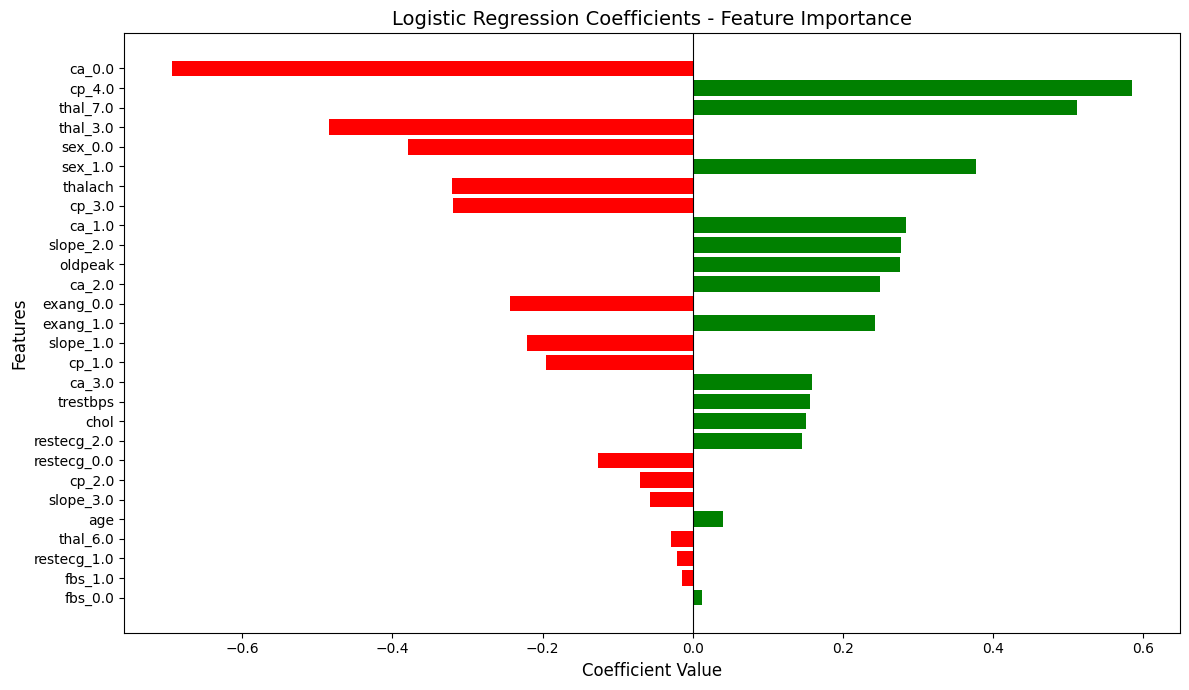

In [131]:
if 'LR' in logistic_regression_models:
    lr_data = logistic_regression_models['LR']
    
    # Tạo DataFrame chi tiết
    lr_coefficients_df = pd.DataFrame({
        "Feature": lr_data["features"],
        "Coefficient": lr_data["coefficients"],
        "Abs_Coefficient": np.abs(lr_data["coefficients"]),
        "Impact": ["Positive" if coef > 0 else "Negative" for coef in lr_data["coefficients"]]
    })
    
    # Sắp xếp theo giá trị tuyệt đối giảm dần
    lr_coefficients_df = lr_coefficients_df.sort_values("Abs_Coefficient", ascending=False)
    lr_coefficients_df = lr_coefficients_df.round(4)
    
    print("\n" + "="*80)
    print("BẢNG HỆ SỐ HỒI QUY LOGISTIC REGRESSION")
    print("="*80)
    print(f"\nBest Parameters: {lr_data['best_params']}")
    print(f"AUC Score: {lr_data['auc']:.4f}")
    print("\n")
    
    # Hiển thị bảng
    from IPython.display import display
    display(lr_coefficients_df)
    
    # Lưu ra file CSV nếu muốn
    lr_coefficients_df.to_csv("logistic_regression_coefficients.csv", index=False)
    print("\n✅ Đã lưu file: logistic_regression_coefficients.csv")
    
    # ============================================
    # THỐNG KÊ TÓM TẮT
    # ============================================
    print("\n" + "="*80)
    print("THỐNG KÊ TÓM TẮT")
    print("="*80)
    
    positive_impact = lr_coefficients_df[lr_coefficients_df["Impact"] == "Positive"]
    negative_impact = lr_coefficients_df[lr_coefficients_df["Impact"] == "Negative"]
    
    print(f"\n📈 Features có tác động TÍCH CỰC (tăng nguy cơ bệnh): {len(positive_impact)} features")
    print(positive_impact[["Feature", "Coefficient"]].to_string(index=False))
    
    print(f"\n📉 Features có tác động TIÊU CỰC (giảm nguy cơ bệnh): {len(negative_impact)} features")
    print(negative_impact[["Feature", "Coefficient"]].to_string(index=False))
    
    # ============================================
    # VẼ BIỂU ĐỒ (tùy chọn)
    # ============================================
    plt.figure(figsize=(12, 7))
    colors = ['green' if coef > 0 else 'red' for coef in lr_coefficients_df["Coefficient"]]
    plt.barh(lr_coefficients_df["Feature"], lr_coefficients_df["Coefficient"], color=colors)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.xlabel("Coefficient Value", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.title("Logistic Regression Coefficients - Feature Importance", fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Không tìm thấy mô hình Logistic Regression trong best_models")

In [132]:
smote_step = SMOTE(sampling_strategy=0.7)

pipe_knn = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("model", KNeighborsClassifier())
])

pipe_lr = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_svm = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("model", SVC(probability=True))
])

pipe_dt = ImbPipeline([
    ("preprocess", preprocess_tree),
    ("smote", smote_step),
    ("model", DecisionTreeClassifier(random_state=42))
])

pipe_rf = ImbPipeline([
    ("preprocess", preprocess_tree),
    ("smote", smote_step),
    ("model", RandomForestClassifier(random_state=42))
])

pipe_bagging = ImbPipeline([
    ("preprocess", preprocess_tree),
    ("smote", smote_step),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100,
        random_state=42
    ))
])

pipe_xgb = ImbPipeline([
    ("preprocess", preprocess_boost),
    ("smote", smote_step),
    ("model", XGBClassifier(eval_metric='logloss', random_state=42))
])

pipe_ada = ImbPipeline([
    ("preprocess", preprocess_boost),
    ("smote", smote_step),
    ("model", AdaBoostClassifier(random_state=42))
])

pipe_cat = ImbPipeline([
    ("preprocess", preprocess_boost),
    ("smote", smote_step),
    ("model", CatBoostClassifier(verbose=0, random_state=42))
])

In [133]:
pipelines_smote = {
    "KNN": pipe_knn,
    "LR": pipe_lr,
    "SVM": pipe_svm,
    "DT": pipe_dt,
    "RF": pipe_rf,
    "Bagging": pipe_bagging,
    "XGB": pipe_xgb,
    "Ada": pipe_ada,
    "CatBoost": pipe_cat
}

In [134]:
best_models = {}
evaluation_results = []

for name, pipe in pipelines_smote.items():
    if name == 'SVM':
        pass
    print(f"[{name}] Đang huấn luyện với GridSearchCV...")
    
    # 1. Huấn luyện GridSearchCV
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        return_train_score=True,
        verbose=1
    )
    
    start_time = time.time()
    
    grid.fit(X_train, Y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    best_models[name] = grid.best_estimator_
    
    
    best_idx = grid.best_index_
    
    # neg_log_loss trả về số âm, nên ta nhân -1 để có giá trị log_loss chuẩn (càng nhỏ càng tốt)
    train_loss = -grid.cv_results_['mean_train_score'][best_idx]
    val_loss_cv = -grid.cv_results_['mean_test_score'][best_idx]
    
    # 2. Dự đoán xác suất cho nhãn Positive (1)
    # SVM của bạn đã có probability=True nên predict_proba sẽ chạy bình thường
    y_probs = grid.best_estimator_.predict_proba(X_test)[:, 1]
    
    # 3. Tính toán ROC AUC và tìm ngưỡng cắt (Threshold) tối ưu
    auc = roc_auc_score(Y_test, y_probs)
    fpr, tpr, thresholds = roc_curve(Y_test, y_probs)
    
    # Sử dụng Youden's J statistic để tìm threshold cắt tối ưu (tối đa hoá tpr - fpr)
    J = tpr - fpr
    optimal_idx = np.argmax(J)
    optimal_threshold = thresholds[optimal_idx]
    
    # 4. Dự đoán dựa trên ngưỡng vừa tìm được
    y_pred = (y_probs >= optimal_threshold).astype(int)
    
    # 5. Đánh giá các độ đo khác
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred, zero_division=0)
    rec = recall_score(Y_test, y_pred, zero_division=0)
    
    evaluation_results.append({
        "Model": name,
        "Training Time (s)": round(training_time, 4),
        "AUC": auc,
        "Optimal Threshold": optimal_threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Best Params": grid.best_params_
    })
    #new
    print(grid.best_params_)
# Tạo DataFrame hiển thị kết quả
results_df = pd.DataFrame(evaluation_results)
results_df.sort_values(by="AUC", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

display(results_df)

[KNN] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


ValueError: 
All the 100 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\imblearn\pipeline.py", line 514, in fit
    Xt, yt = self._fit(X, y, routed_params, raw_params=params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:

pca_step = PCA() # Để trống tham số này để Param Grid tự tune

# TẤT CẢ các model đều phải dùng preprocess_scaled vì có PCA
pipe_knn = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", KNeighborsClassifier())
])

pipe_lr = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", LogisticRegression())
])

pipe_svm = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", SVC(probability=True))
])

pipe_dt = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", DecisionTreeClassifier())
])

pipe_rf = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", RandomForestClassifier())
])

pipe_bagging = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100
    ))
])

pipe_xgb = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", XGBClassifier(eval_metric='logloss'))
])

pipe_ada = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", AdaBoostClassifier())
])

pipe_cat = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", CatBoostClassifier(verbose=0))
])

pipelines_smote_pca = {
    "KNN": pipe_knn,
    "LR": pipe_lr,
    "SVM": pipe_svm,
    "DT": pipe_dt,
    "RF": pipe_rf,
    "Bagging": pipe_bagging,
    "XGB": pipe_xgb,
    "Ada": pipe_ada,
    "CatBoost": pipe_cat
}

In [ ]:
param_knn = {
    "pca__n_components": [0.90, 0.95],
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

param_lr = {
    "pca__n_components": [0.90, 0.95],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

param_svm = {
    "pca__n_components": [0.90, 0.95],
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["rbf", "linear"],
    "model__gamma": ["scale", "auto"]
}

param_dt = {
    "pca__n_components": [0.90, 0.95],
    "model__max_depth": [3, 5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__criterion": ["gini", "entropy"]
}

param_rf = {
    "pca__n_components": [0.90, 0.95],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

param_bagging = {
    "pca__n_components": [0.90, 0.95],
    "model__n_estimators": [50, 100, 200],
    "model__max_samples": [0.5, 0.7, 1.0],
    "model__max_features": [0.5, 0.7, 1.0]
}

param_xgb = {
    "pca__n_components": [0.90, 0.95],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

param_ada = {
    "pca__n_components": [0.90, 0.95],
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.1, 1]
}

param_cat = {
    "pca__n_components": [0.90, 0.95],
    "model__iterations": [100, 200, 300],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.01, 0.1]
    # Bỏ l2_leaf_reg đi bớt để giảm thời gian train nếu bạn kết hợp cả PCA
}

param_grids_smote_pca = {
    "KNN": param_knn,
    "LR": param_lr,
    "SVM": param_svm,
    "DT": param_dt,
    "RF": param_rf,
    "Bagging": param_bagging,
    "XGB": param_xgb,
    "Ada": param_ada,
    "CatBoost": param_cat
}

In [ ]:
best_models = {}
evaluation_results = []

for name, pipe in pipelines_smote_pca.items():
    if name == 'SVM' or name == 'Bagging' or name == 'CatBoost':
        continue
    print(f"[{name}] Đang huấn luyện với GridSearchCV...")
    
    # 1. Huấn luyện GridSearchCV
    grid = GridSearchCV(
        pipe,
        param_grids_smote_pca[name],
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        return_train_score=True,
        verbose=1
    )
    
    start_time = time.time()
    
    grid.fit(X_train, Y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    best_models[name] = grid.best_estimator_
    
    
    # 2. Dự đoán xác suất cho nhãn Positive (1)
    # SVM của bạn đã có probability=True nên predict_proba sẽ chạy bình thường
    y_probs = grid.best_estimator_.predict_proba(X_test)[:, 1]
    
    # 3. Tính toán ROC AUC và tìm ngưỡng cắt (Threshold) tối ưu
    auc = roc_auc_score(Y_test, y_probs)
    fpr, tpr, thresholds = roc_curve(Y_test, y_probs)
    
    # Sử dụng Youden's J statistic để tìm threshold cắt tối ưu (tối đa hoá tpr - fpr)
    J = tpr - fpr
    optimal_idx = np.argmax(J)
    optimal_threshold = thresholds[optimal_idx]
    
    # 4. Dự đoán dựa trên ngưỡng vừa tìm được
    y_pred = (y_probs >= optimal_threshold).astype(int)
    
    # 5. Đánh giá các độ đo khác
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred, zero_division=0)
    rec = recall_score(Y_test, y_pred, zero_division=0)
    
    evaluation_results.append({
        "Model": name,
        "Training Time (s)": round(training_time, 4),
        "AUC": auc,
        "Optimal Threshold": optimal_threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Best Params": grid.best_params_
    })
    print(grid.best_params_)
# Tạo DataFrame hiển thị kết quả
results_df = pd.DataFrame(evaluation_results)
results_df.sort_values(by="AUC", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

display(results_df)

[KNN] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
{'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'uniform', 'pca__n_components': 0.95}
[LR] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'pca__n_components': 0.95}
[DT] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 180 candidates, totalling 900 fits
{'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'pca__n_components': 0.9}
[RF] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300, 'pca__n_components': 0.95}
[XGB] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8, 'pca__n_components': 0.9}
[Ada] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
{'model__learning_rate': 0.1, 'model__n_e

,Model,Training Time (s),AUC,Optimal Threshold,Accuracy,Precision,Recall,Best Params
0,LR,1.1030,0.934837,0.309270,0.898305,0.800000,0.952381,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod..."
1,KNN,3.6347,0.931078,0.333333,0.847458,0.714286,0.952381,"{'model__n_neighbors': 9, 'model__p': 1, 'mode..."
2,XGB,54.5843,0.919799,0.364914,0.847458,0.750000,0.857143,"{'model__colsample_bytree': 1.0, 'model__learn..."
3,Ada,11.4109,0.911028,0.457818,0.881356,0.791667,0.904762,"{'model__learning_rate': 0.1, 'model__n_estima..."
4,RF,60.1662,0.902256,0.302478,0.847458,0.700000,1.000000,"{'model__max_depth': 5, 'model__min_samples_le..."
5,DT,15.8438,0.792607,0.424658,0.728814,0.580645,0.857143,"{'model__criterion': 'entropy', 'model__max_de..."
